# Ejercicios 2

#### 1.- Crea una caja en 2d de tamaño 1000 con las siguientes distribuciones



##### a) Puntos en una malla cuadriculada de distancia (10x10 cada retícula) Nota: Que cada punto tenga una distancia de 100x100 entre cada punto, puntos separados como si fuese una malla uniforme 

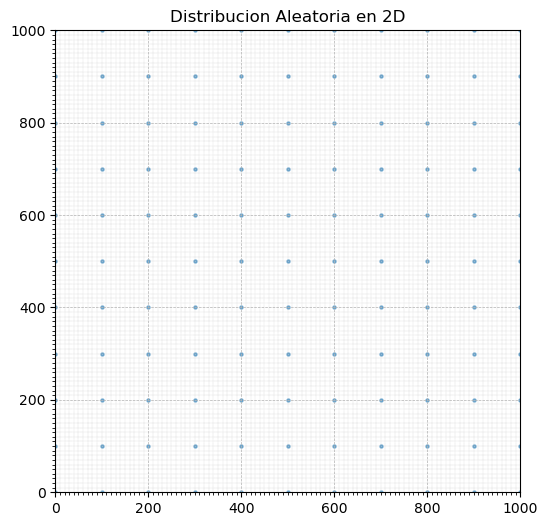

121


In [60]:
import sympy as owo
import numpy as uwu
import matplotlib as mlp
import matplotlib.pyplot as plt
from scipy import special
import math
import pandas as pd
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D



def spawn_puntos(n, d, t):
    if d == 2:
        x =  uwu.random.uniform(0, t, n) #Genera numeros aleatorios de 0 a t en x
        y = uwu.random.uniform(0, t ,n) #Genera numeros aleatorios de 0 a t en x
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
    elif d == 3:
        x = uwu.random.uniform(0, t, n)
        y = uwu.random.uniform(0, t, n)
        z = uwu.random.uniform(0, t, n)
        puntos = uwu.vstack((x, y, z)).T #Ordena los datos en una matriz de n x 3
    return puntos

def grafica_2d(p,tam): #Grafica los puntos aleatorios en 2d
    plt.figure(figsize=(6,6))
    plt.scatter(p[:,0], p[:,1], alpha=0.5, s=5) #Toma los valores en x e y en el spawn de puntos y los grafica
    plt.xlim(0, tam)
    plt.ylim(0, tam)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(uwu.arange(0, tam+1, 200)) # Ejes cada 200 unidades
    plt.yticks(uwu.arange(0, tam+1, 200))
    ax = plt.gca()
    ax.set_xticks(uwu.arange(0, tam+1, 10), minor=True) # Cuadriculado de 10x10
    ax.set_yticks(uwu.arange(0, tam+1, 10), minor=True)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3)
    plt.title("Distribucion Aleatoria en 2D")
    plt.show()

def grafica_3d(p,tam): #Grafica los puntos aleatorios en 3d
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(p[:,0], p[:,1], p[:,2], alpha=0.5, s=10) #Toma los valores en x, y, z en el spawn de puntos y los grafica
    ax.set_xlim([0, tam])
    ax.set_ylim([0, tam])
    ax.set_zlim([0, tam])
    ax.set_xticks(uwu.arange(0, tam+1, 200)) # Ejes cada 200 unidades
    ax.set_yticks(uwu.arange(0, tam+1, 200))
    ax.set_zticks(uwu.arange(0, tam+1, 200)) 
    
    ax.set_xticks(uwu.arange(0, tam+1, 10), minor=True) # Cuadriculado de 10x10
    ax.set_yticks(uwu.arange(0, tam+1, 10), minor=True)
    ax.set_zticks(uwu.arange(0, tam+1, 10), minor=True)
    
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3) # Cuadriculado en 3D
    ax.set_title("Distribucion Aleatoria en 3D")
    plt.show()

#Malla Cuadriculada


def generar_malla(ancho, alto, distancia=100):
    
    puntos_malla = uwu.vstack([(x, y) for x in range(0, ancho + 1, distancia) 
    for y in range(0, alto + 1, distancia)]) #La 'distancia' en range, genera el espaciado desado en la generacion de cada punto
    return puntos_malla


# Caracteristicas de la grafica

dim = 2  # Dimension
num_p = 1000  # Cantidad de puntos
tam=1000   #Tamaño del grafico
puntos_RR = spawn_puntos(num_p, dim, tam) #Genera los puntos, segun las caracteristicas anteriores

puntos_malla = generar_malla(tam, tam)
num_p_malla=int( (tam/100+1)**2 )
if dim == 2:
    grafica_2d(puntos_malla,tam)
elif dim == 3:
    grafica_3d(puntos_RR,tam)

print(num_p_malla)

##### b) 1000 puntos sobre un disco de radio 300

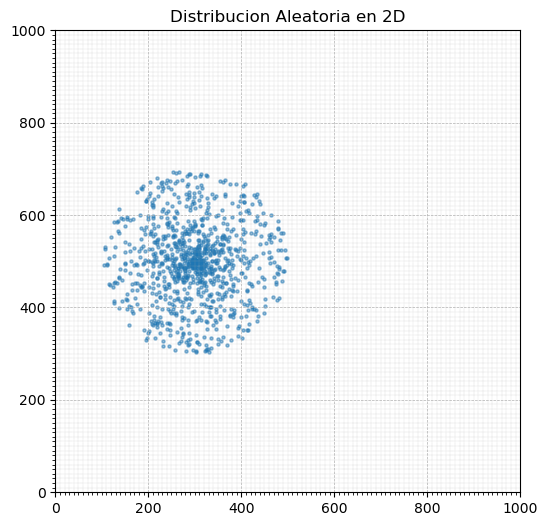

In [62]:
def spawn_puntos_disco(n, t, r,centro):
        #Centro debe ser un punto en el plano.
        angulos = uwu.random.uniform(0, 2*uwu.pi, n) #Genera angulos entre 0 a 2\pi
        radios = uwu.random.uniform(0, r, n)   # Generar radios de 0 a r NOTA: Se debe cambiar a radios al cuadrado para dar una distribucion uniforme
        x = radios * uwu.cos(angulos) #Transformacion de polares a cartesianas
        y = radios * uwu.sin(angulos)
        x += centro[0]  #Traslada el centro a las coordenadas de eleccion 
        y += centro[1]
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
        return puntos

def grafica_2d(p,tam): #Grafica los puntos aleatorios en 2d
    plt.figure(figsize=(6,6))
    plt.scatter(p[:,0], p[:,1], alpha=0.5, s=5) #Toma los valores en x e y en el spawn de puntos y los grafica
    plt.xlim(0, tam) #Tam define el tamaño del grafico 
    plt.ylim(0, tam)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(uwu.arange(0, tam+1, 200)) # Ejes cada 200 unidades
    plt.yticks(uwu.arange(0, tam+1, 200))
    ax = plt.gca()
    ax.set_xticks(uwu.arange(0, tam+1, 10), minor=True) # Cuadriculado de 10x10
    ax.set_yticks(uwu.arange(0, tam+1, 10), minor=True)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3)
    plt.title("Distribucion Aleatoria en 2D")
    plt.show()

# Caracteristicas de la grafica
r=200 #Radio
num_p = 1000  # Cantidad de puntos
tam=1000   #Tamaño del grafico
centro=(300, 500) #Centro donde se generan los puntos del disco 

pDD_disco = spawn_puntos_disco(num_p, tam,r,centro) #Genera los puntos, segun las caracteristicas anteriores
grafica_2d(pDD_disco,tam)


##### c) 1000 puntos sobre un anillo con radio mayor 300 y radio menor 290

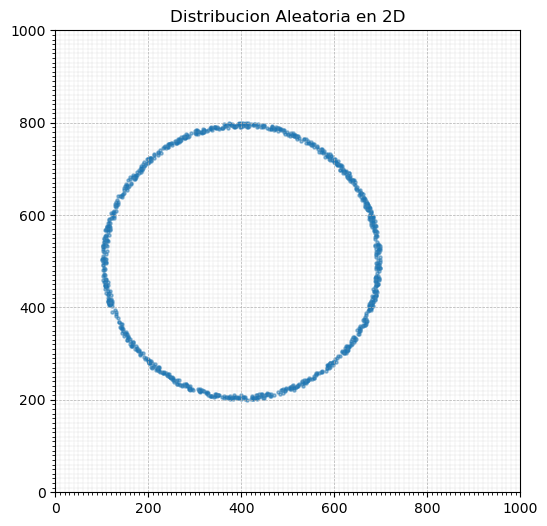

In [64]:
def spawn_puntos_anillo(n, t, rm,rM,centro):
        #Centro debe ser un punto en el plano.
    
        angulos = uwu.random.uniform(0, 2*uwu.pi, n) #Genera angulos entre 0 a 2\pi
        radios = uwu.random.uniform(rm, rM, n)   # Generar radios de 0 a r, rm es el radio menor y rM el radio mayor del anillo
        x = radios * uwu.cos(angulos) #Transformacion de polares a cartesianas
        y = radios * uwu.sin(angulos)
        x += centro[0]  #Traslada el centro a las coordenadas de eleccion 
        y += centro[1]
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
        return puntos

def grafica_2d(p,tam): #Grafica los puntos aleatorios en 2d
    plt.figure(figsize=(6,6))
    plt.scatter(p[:,0], p[:,1], alpha=0.5, s=5) #Toma los valores en x e y en el spawn de puntos y los grafica
    plt.xlim(0, tam) #Tam define el tamaño del grafico 
    plt.ylim(0, tam)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(uwu.arange(0, tam+1, 200)) # Ejes cada 200 unidades
    plt.yticks(uwu.arange(0, tam+1, 200))
    ax = plt.gca()
    ax.set_xticks(uwu.arange(0, tam+1, 10), minor=True) # Cuadriculado de 10x10
    ax.set_yticks(uwu.arange(0, tam+1, 10), minor=True)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3)
    plt.title("Distribucion Aleatoria en 2D")
    plt.show()

# Caracteristicas de la grafica
r1=290 #Radio menor
r2=300 #Radio mayor
num_p = 1000  # Cantidad de puntos
tam=1000   #Tamaño del grafico
centro=(400, 500) #Centro donde se generan los puntos del disco 

pDD_anillo= spawn_puntos_anillo(num_p, tam,r1,r2,centro) #Genera los puntos, segun las caracteristicas anteriores
grafica_2d(pDD_anillo,tam)

##### d) 50 anillos con 100 puntos cada uno cuyos centros están distribuidos aleatoriamente sobre la caja

<Figure size 800x800 with 0 Axes>

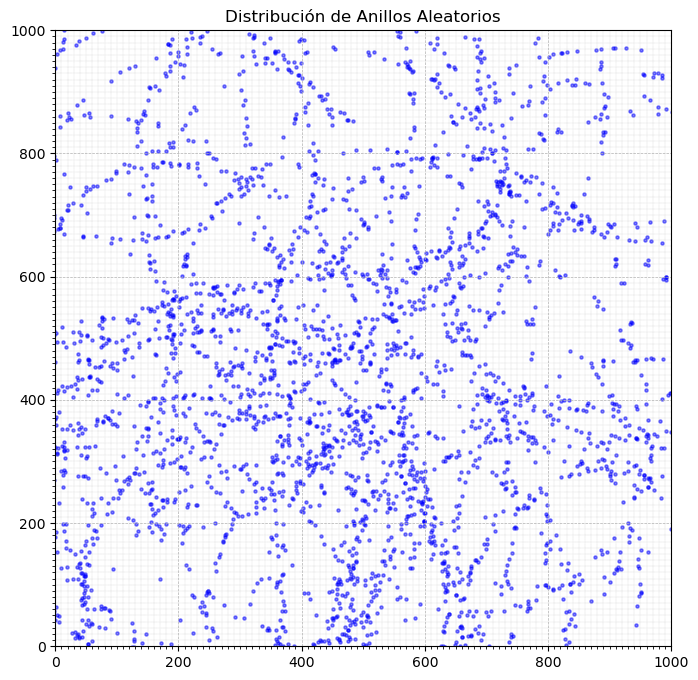

In [66]:

def anillos_distribuidos(num_centros, tam,r1,r2,num_p): #Funcion que grafica todos los anillos
    plt.figure(figsize=(8, 8)) #Inicia la figura
    puntos_anillos = [] #Lista que guardara todos los puntos generados
    for i in range(num_centros):
        centro=(uwu.random.uniform(0, tam), uwu.random.uniform(0, tam)) #Genera el centro aleatorio
        p = spawn_puntos_anillo(num_p, tam,r1,r2,centro) #Genera los puntos, segun las caracteristicas anteriores
        puntos_anillos.append(p) #Va guardando cada anillo en la lista 
        #plt.scatter(p[:,0], p[:,1], alpha=0.5, s=5, color='blue') #Grafica el anillo generado de cada iteracion
    puntos_anillos = uwu.vstack(puntos_anillos) if puntos_anillos else uwu.array([]) # Transforma la lista de arrays en un solo array usando vstack
    return puntos_anillos

# Caracteristicas 
r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
tam=1000   #Tamaño del grafico
num_centros=50 #Numero de centros o anillos a graficar

pDD_anillos=anillos_distribuidos(num_centros,tam,r1,r2,num_pa)

#Muestra la grafica resultante con las divisiones de los incisos anteriores 
plt.figure(figsize=(8, 8))
plt.scatter(pDD_anillos[:,0], pDD_anillos[:,1], alpha=0.5, s=5, color='blue')
plt.xlim(0, tam)
plt.ylim(0, tam)
plt.gca().set_aspect('equal', adjustable='box')  # Asegura que los ejes tengan la misma escala
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(uwu.arange(0, tam+1, 200)) # Ejes cada 200 unidades
plt.yticks(uwu.arange(0, tam+1, 200))
ax = plt.gca()
ax.set_xticks(uwu.arange(0, tam+1, 10), minor=True) # Cuadriculado de 10x10
ax.set_yticks(uwu.arange(0, tam+1, 10), minor=True)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3)
plt.title("Distribución de Anillos Aleatorios")
plt.show()


#### 2.- Haz un algoritmo que calcule la función de correlación con DD/RR-1 con el mismo número de puntos aleatorios que datos, y comprueba que si usas muestras aleatorias la función de correlación es cero. Cambia el número de puntos y el tamaño de bin, y observa qué ocurre.

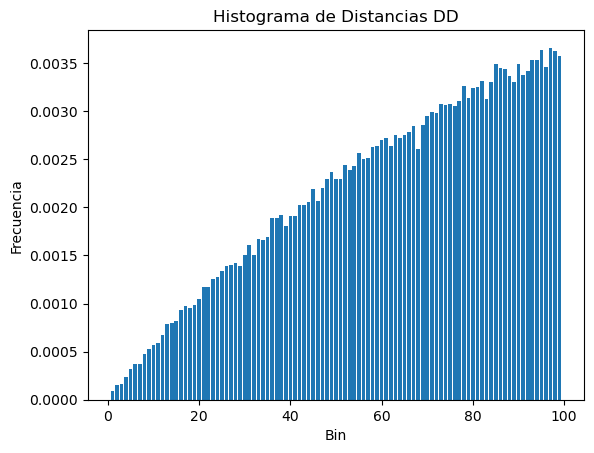

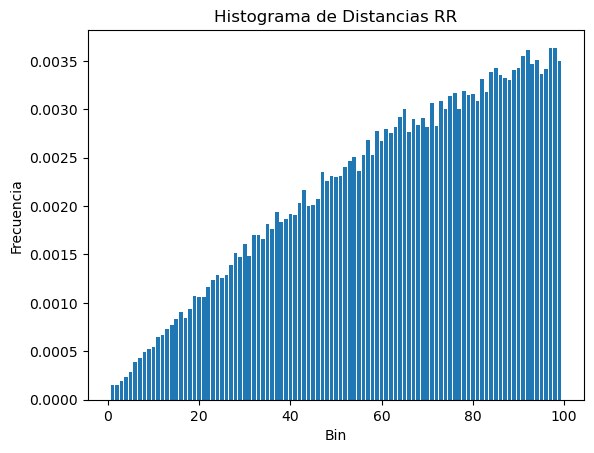

In [68]:
def Histo_distancias(d, dim_hist, num_p, p, bin_size): #Funcion que calcula el histograma
    Hist = uwu.zeros(dim_hist)
    
    if d == 2:
        for i in range(num_p):
            for j in range(i + 1, num_p):
                dist = uwu.sqrt((p[i, 0] - p[j, 0]) ** 2 + (p[i, 1] - p[j, 1]) ** 2)
                bin = int(dist / bin_size)  # Calcula a qué bin pertenece.
                
                if bin >= dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                    Hist[0] += 1  
                else:
                    Hist[max(1, bin)] += 1  # Si bin=0, se registra en Hist[1], de otro modo en Hist[bin]
                    
    elif d == 3:
        for i in range(num_p):
            for j in range(i + 1, num_p):
                dist = uwu.sqrt((p[i, 0] - p[j, 0]) ** 2 + (p[i, 1] - p[j, 1]) ** 2 + (p[i, 2] - p[j, 2]) ** 2)
                bin = int(dist / bin_size) 
                if bin >= dim_hist:  
                    Hist[0] += 1  
                else:
                    Hist[max(1, bin)] += 1 
                    
    return Hist

bin_size = 3  # Tamaño del Bin
dim_hist = 100  # Número de Bins: en realidad el numero es dim_hist-1, ya que, Hist[0] guarda todos los valores fuera de los rangos que estamos considerando.
dim=2
tam=1000   #Tamaño del grafico
num_pDD=1000
num_pRR =1000  # Cantidad de puntos

pDD= spawn_puntos(num_pDD, dim, tam) #Genera los puntos de la muestra de datos
pRR=spawn_puntos(num_pRR,dim, tam) #Genera los puntos de la muestra aleatoria (aunque en realidad los dos lo son)

Histo_PuntosDD = Histo_distancias(dim, dim_hist, num_pDD, pDD, bin_size)  #Obtiene el histograma de los datos (los anillos generados)
Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pRR, pRR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_DD=0
l_RR=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DD=l_DD+Histo_PuntosDD[k]
    l_RR=l_RR+Histo_PuntosRR[k]

Histo_Punto_DDN=Histo_PuntosDD/l_DD # DD normalizado
Histo_Punto_RRN=Histo_PuntosRR/l_RR #RR normalizado

# Grafica el histograma 
plt.bar(range(1, dim_hist), Histo_Punto_DDN[1:], align='center')  #Histograma de DD
plt.xlabel("Bin")
plt.ylabel("Frecuencia")
plt.title("Histograma de Distancias DD")
plt.show()

plt.bar(range(1, dim_hist), Histo_Punto_RRN[1:], align='center')  #Histograma de RR
plt.xlabel("Bin")
plt.ylabel("Frecuencia")
plt.title("Histograma de Distancias RR")
plt.show()


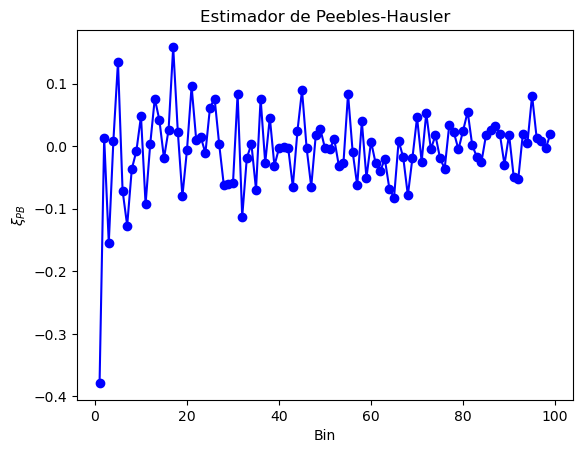

In [69]:
PlebesH=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH[i]=(Histo_Punto_DDN[i])/(Histo_Punto_RRN[i])-1

# Grafica el histograma 
plt.plot(range(1, dim_hist), PlebesH[1:], marker='o', color='b',linestyle="solid") #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("Estimador de Peebles-Hausler")
plt.show()


#### Calcula la función de correlación para cada una de las cajas de datos del inciso anterior, usando los estimadores de

#### a) Peebles-Hauser

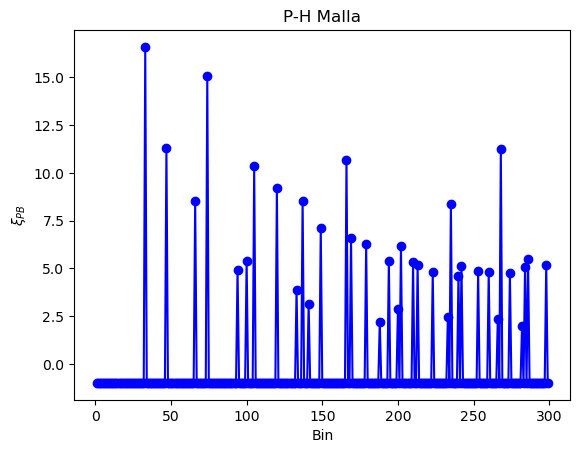

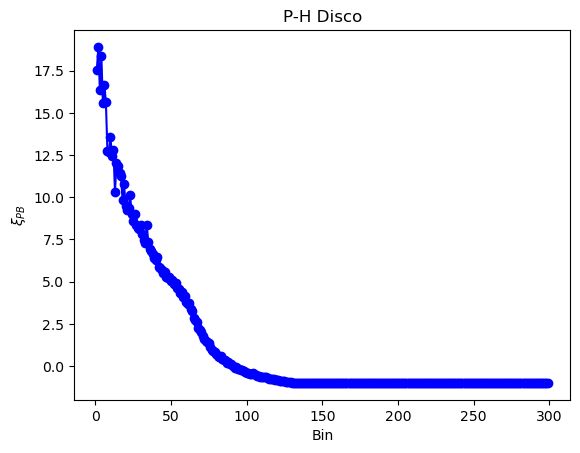

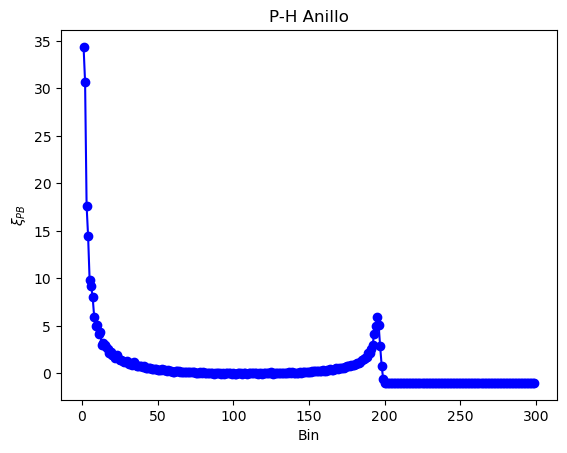

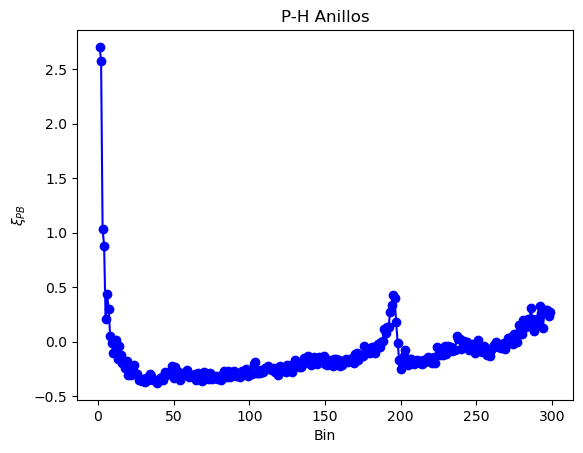

In [86]:
# Caracteristicas del anillo

r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
num_centros=10 #Numero de centros o anillos a graficar

#Caracteristicas Generales

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=1000 #Tamaño de la grafica
num_pG=1000 #Numero de puntos de datos 
num_p_a=10000 #Numero de puntos aleatorios (10 veces el numero de datos)

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

# Malla Cuadriculada 

Histo_PuntosDMalla = Histo_distancias(dim, dim_hist, num_p_malla, puntos_malla, bin_size)  

l_DMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DMalla=l_DMalla+Histo_PuntosDMalla[k]

Histo_Punto_DMalla_N=Histo_PuntosDMalla/l_DMalla # DD normalizado

PlebesH_DMalla=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_DMalla[i]=(Histo_Punto_DMalla_N[i])/(Histo_PuntosRR_N[i])-1

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_DMalla[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("P-H Malla")
plt.show()



#Disco

Histo_PuntosDDisco = Histo_distancias(dim, dim_hist, num_pG, pDD_disco, bin_size)  

l_DDisco=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DDisco=l_DDisco+Histo_PuntosDDisco[k]

Histo_Punto_DDisco_N=Histo_PuntosDDisco/l_DDisco # DD normalizado

PlebesH_Disco=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Disco[i]=(Histo_Punto_DDisco_N[i])/(Histo_PuntosRR_N[i])-1

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Disco[1:], marker='o', color='b',linestyle="solid") #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("P-H Disco")
plt.show()


#Anillo

Histo_PuntosDAnillo= Histo_distancias(dim, dim_hist, num_pG, pDD_anillo, bin_size)  

l_DAnillo=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillo=l_DAnillo+Histo_PuntosDAnillo[k]

Histo_Punto_DAnillo_N=Histo_PuntosDAnillo/l_DAnillo # DD normalizado

PlebesH_Anillo=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Anillo[i]=(Histo_Punto_DAnillo_N[i])/(Histo_PuntosRR_N[i])-1

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Anillo[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("P-H Anillo")
plt.show()

#Anillos

num_pDD_anillos=num_pa*num_centros

Histo_PuntosDAnillos = Histo_distancias(dim, dim_hist, num_pDD_anillos, pDD_anillos, bin_size)  #Obtiene el histograma de los datos (los anillos generados)

l_DAnillos=0

for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillos=l_DAnillos+Histo_PuntosDAnillos[k]

Histo_Punto_DAnillos_N=Histo_PuntosDAnillos/l_DAnillos # DD normalizado

PlebesH_Anillos=uwu.zeros(dim_hist)  #Lista que guardara los calculos del la funcion Peebles-Hausler 

for i in range(1,dim_hist):
    PlebesH_Anillos[i]=(Histo_Punto_DAnillos_N[i])/(Histo_PuntosRR_N[i])-1

plt.plot(range(1, dim_hist), PlebesH_Anillos[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("P-H Anillos")
plt.show()







#### b) David-Peebles

##### Primero programamos una funcion que calcule DR:

In [89]:
def Histo_DR(dim_hist, num_pdatos,num_paleatorios, p_datos,p_aleatorios, bin_size): #Funcion que calcula DR
    Hist = uwu.zeros(dim_hist)
    for i in range(num_pdatos):
        for j in range(num_paleatorios):
            dist = uwu.sqrt((p_datos[i, 0] - p_aleatorios[j, 0]) ** 2 + (p_datos[i, 1] - p_aleatorios[j, 1]) ** 2)
            bin = int(dist / bin_size)  # Calcula a qué bin pertenece.
                
            if bin >= dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                    Hist[0] += 1  
            else:
                Hist[max(1, bin)] += 1  # Si bin=0, se registra en Hist[1], de otro modo en Hist[bin]
                    
    return Hist



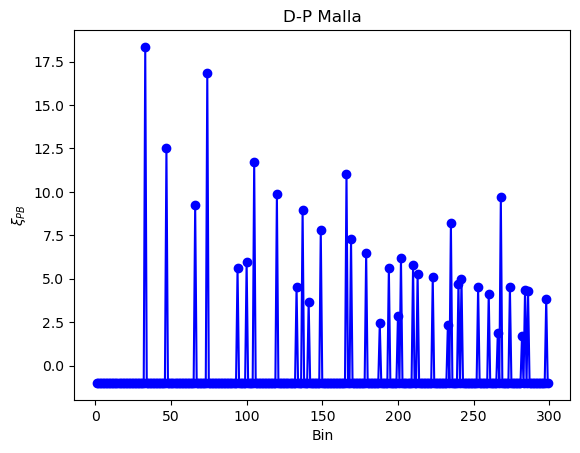

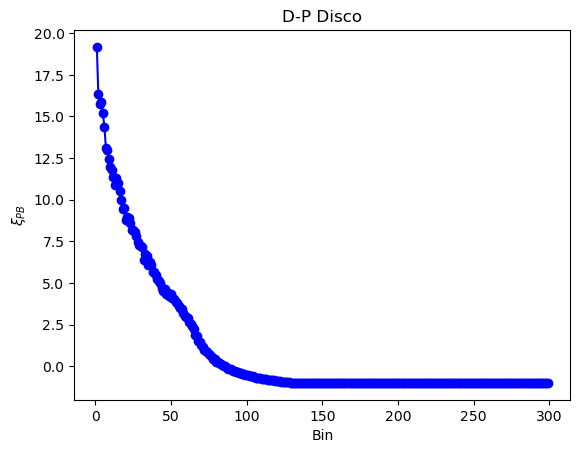

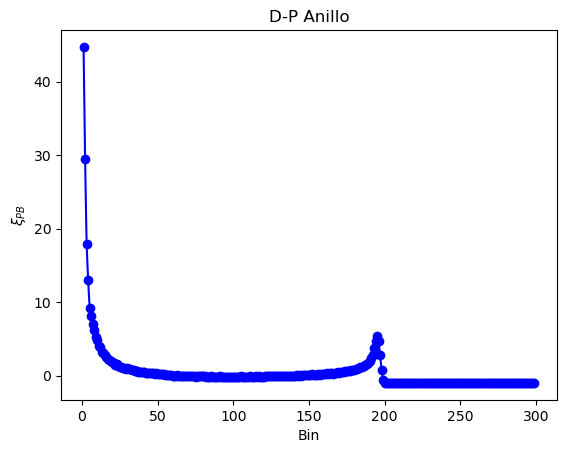

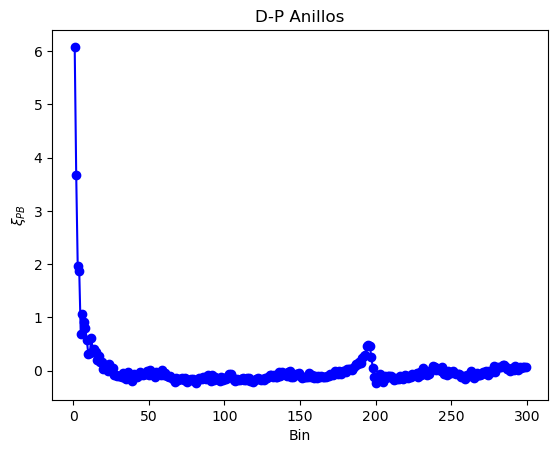

In [90]:
# Caracteristicas del anillo

r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
num_centros=10 #Numero de centros o anillos a graficar

#Caracteristicas Generales

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=1000 #Tamaño de la grafica
num_pG=1000 #Numero de puntos de datos 
num_p_a=10000 #Numero de puntos aleatorios (10 veces el numero de datos)

puntos_RR = spawn_puntos(num_p_a, dim, tam)

# Malla Cuadriculada 

Histo_PuntosDRMalla =  Histo_DR(dim_hist, num_p_malla, num_p_a, puntos_malla, puntos_RR, bin_size) #DR Malla
l_DRMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRMalla=l_DRMalla+Histo_PuntosDRMalla[k]

Histo_Punto_DRMalla_N=Histo_PuntosDRMalla/l_DRMalla # DR normalizado

Histo_PuntosDMalla = Histo_distancias(dim, dim_hist, num_p_malla, puntos_malla, bin_size)  

l_DMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DMalla=l_DMalla+Histo_PuntosDMalla[k]

Histo_Punto_DMalla_N=Histo_PuntosDMalla/l_DMalla # DD normalizado

PlebesH_DMalla=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_DMalla[i]=(Histo_Punto_DMalla_N[i])/(Histo_Punto_DRMalla_N[i])-1

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_DMalla[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("D-P Malla")
plt.show()

#Disco

Histo_PuntosDRDisco =  Histo_DR(dim_hist, num_pG, num_p_a, pDD_disco, puntos_RR, bin_size) #DR Malla
l_DRDisco=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRDisco=l_DRDisco+Histo_PuntosDRDisco[k]

Histo_Punto_DRDisco_N=Histo_PuntosDRDisco/l_DRDisco # DR normalizado

Histo_PuntosDDisco = Histo_distancias(dim, dim_hist, num_pG, pDD_disco, bin_size)  

l_DDisco=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DDisco=l_DDisco+Histo_PuntosDDisco[k]

Histo_Punto_DDisco_N=Histo_PuntosDDisco/l_DDisco # DD normalizado

PlebesH_Disco=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Disco[i]=(Histo_Punto_DDisco_N[i])/(Histo_Punto_DRDisco_N[i])-1

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Disco[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("D-P Disco")
plt.show()

#Anillo

Histo_PuntosDRAnillo =  Histo_DR(dim_hist, num_pG, num_p_a, pDD_anillo, puntos_RR, bin_size) #DR Malla
l_DRAnillo=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillo=l_DRAnillo+Histo_PuntosDRAnillo[k]

Histo_Punto_DRAnillo_N=Histo_PuntosDRAnillo/l_DRAnillo # DR normalizado 

Histo_PuntosDAnillo= Histo_distancias(dim, dim_hist, num_pG, pDD_anillo, bin_size)  

l_DAnillo=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillo=l_DAnillo+Histo_PuntosDAnillo[k]

Histo_Punto_DAnillo_N=Histo_PuntosDAnillo/l_DAnillo # DD normalizado

PlebesH_Anillo=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Anillo[i]=(Histo_Punto_DAnillo_N[i])/(Histo_Punto_DRAnillo_N[i])-1

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Anillo[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("D-P Anillo")
plt.show()

#Anillos

num_pDD_anillos=num_pa*num_centros

Histo_PuntosDRAnillos =  Histo_DR(dim_hist, num_pG, num_pDD_anillos, pDD_anillos, puntos_RR, bin_size) #DR Malla
l_DRAnillos=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillos=l_DRAnillos+Histo_PuntosDRAnillos[k]

Histo_Punto_DRAnillos_N=Histo_PuntosDRAnillos/l_DRAnillos # DR normalizado 

Histo_PuntosDAnillos = Histo_distancias(dim, dim_hist, num_pDD_anillos, pDD_anillos, bin_size)  #Obtiene el histograma de los datos (los anillos generados)

l_DAnillos=0

for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillos=l_DAnillos+Histo_PuntosDAnillos[k]

Histo_Punto_DAnillos_N=Histo_PuntosDAnillos/l_DAnillos # DD normalizado

PlebesH_Anillos=uwu.zeros(dim_hist)  #Lista que guardara los calculos del la funcion Peebles-Hausler 

for i in range(1,dim_hist):
    PlebesH_Anillos[i]=(Histo_Punto_DAnillos_N[i])/(Histo_Punto_DRAnillos_N[i])-1


plt.plot(range(1, dim_hist), PlebesH_Anillos[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("D-P Anillos")
plt.show()



#### c) Hamilton 

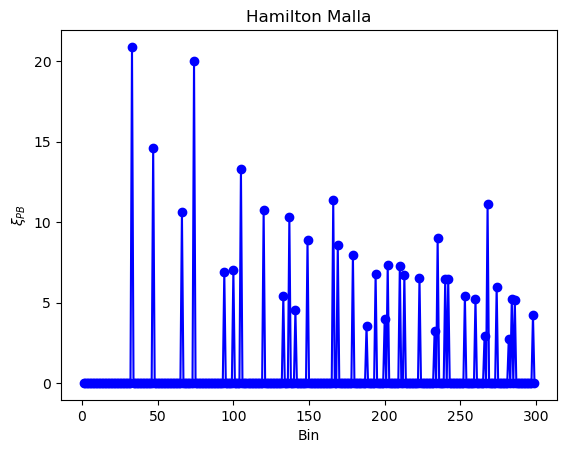

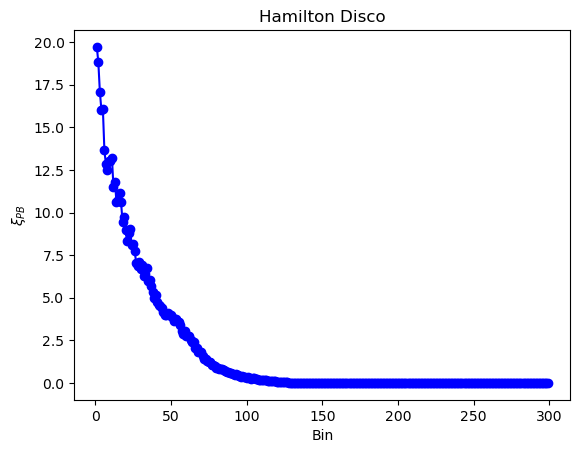

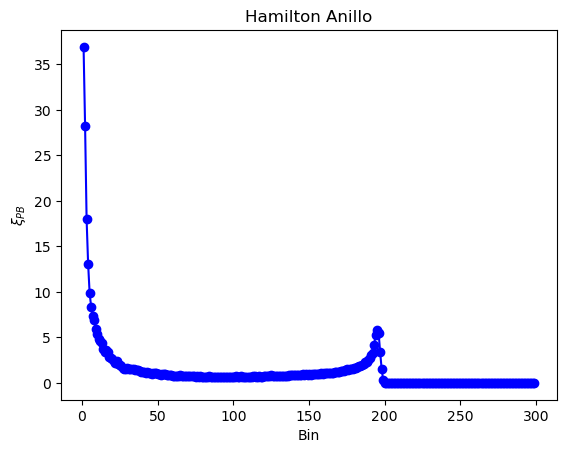

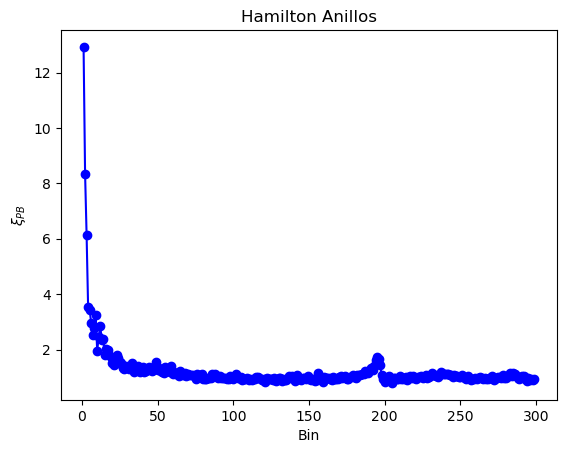

In [92]:
# Caracteristicas del anillo

r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
num_centros=10 #Numero de centros o anillos a graficar

#Caracteristicas Generales

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=1000 #Tamaño de la grafica
num_pG=1000 #Numero de puntos de datos 
num_p_a=10000 #Numero de puntos aleatorios (10 veces el numero de datos)

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

# Malla Cuadriculada 

Histo_PuntosDRMalla =  Histo_DR(dim_hist, num_p_malla, num_p_a, puntos_malla, puntos_RR, bin_size) #DR Malla
l_DRMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRMalla=l_DRMalla+Histo_PuntosDRMalla[k]

Histo_Punto_DRMalla_N=Histo_PuntosDRMalla/l_DRMalla # DR normalizado

Histo_PuntosDMalla = Histo_distancias(dim, dim_hist, num_p_malla, puntos_malla, bin_size)  

l_DMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DMalla=l_DMalla+Histo_PuntosDMalla[k]

Histo_Punto_DMalla_N=Histo_PuntosDMalla/l_DMalla # DD normalizado

PlebesH_DMalla=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_DMalla[i]=(Histo_PuntosRR_N[i]*Histo_Punto_DMalla_N[i])/(Histo_Punto_DRMalla_N[i])**2

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_DMalla[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("Hamilton Malla")
plt.show()

#Disco

Histo_PuntosDRDisco =  Histo_DR(dim_hist, num_pG, num_p_a, pDD_disco, puntos_RR, bin_size) #DR Malla
l_DRDisco=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRDisco=l_DRDisco+Histo_PuntosDRDisco[k]

Histo_Punto_DRDisco_N=Histo_PuntosDRDisco/l_DRDisco # DR normalizado

Histo_PuntosDDisco = Histo_distancias(dim, dim_hist, num_pG, pDD_disco, bin_size)  

l_DDisco=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DDisco=l_DDisco+Histo_PuntosDDisco[k]

Histo_Punto_DDisco_N=Histo_PuntosDDisco/l_DDisco # DD normalizado

PlebesH_Disco=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Disco[i]=(Histo_PuntosRR_N[i]*Histo_Punto_DDisco_N[i])/(Histo_Punto_DRDisco_N[i])**2

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Disco[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("Hamilton Disco")
plt.show()

#Anillo

Histo_PuntosDRAnillo =  Histo_DR(dim_hist, num_pG, num_p_a, pDD_anillo, puntos_RR, bin_size) #DR Malla
l_DRAnillo=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillo=l_DRAnillo+Histo_PuntosDRAnillo[k]

Histo_Punto_DRAnillo_N=Histo_PuntosDRAnillo/l_DRAnillo # DR normalizado 

Histo_PuntosDAnillo= Histo_distancias(dim, dim_hist, num_pG, pDD_anillo, bin_size)  

l_DAnillo=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillo=l_DAnillo+Histo_PuntosDAnillo[k]

Histo_Punto_DAnillo_N=Histo_PuntosDAnillo/l_DAnillo # DD normalizado

PlebesH_Anillo=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Anillo[i]=(Histo_PuntosRR_N[i]*Histo_Punto_DAnillo_N[i])/(Histo_Punto_DRAnillo_N[i])**2

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Anillo[1:], marker='o', color='b',linestyle="solid") #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("Hamilton Anillo")
plt.show()

#Anillos

num_pDD_anillos=num_pa*num_centros

Histo_PuntosDRAnillos =  Histo_DR(dim_hist, num_pG, num_pDD_anillos, pDD_anillos, puntos_RR, bin_size) #DR Malla
l_DRAnillos=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillos=l_DRAnillos+Histo_PuntosDRAnillos[k]

Histo_Punto_DRAnillos_N=Histo_PuntosDRAnillos/l_DRAnillos # DR normalizado 

Histo_PuntosDAnillos = Histo_distancias(dim, dim_hist, num_pDD_anillos, pDD_anillos, bin_size)  #Obtiene el histograma de los datos (los anillos generados)

l_DAnillos=0

for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillos=l_DAnillos+Histo_PuntosDAnillos[k]

Histo_Punto_DAnillos_N=Histo_PuntosDAnillos/l_DAnillos # DD normalizado

PlebesH_Anillos=uwu.zeros(dim_hist)  #Lista que guardara los calculos del la funcion Peebles-Hausler 

for i in range(1,dim_hist):
    PlebesH_Anillos[i]=(Histo_PuntosRR_N[i]*Histo_Punto_DAnillos_N[i])/(Histo_Punto_DRAnillos_N[i])**2


plt.plot(range(1, dim_hist), PlebesH_Anillos[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("Hamilton Anillos")
plt.show()





#### d) Landy-Szalay

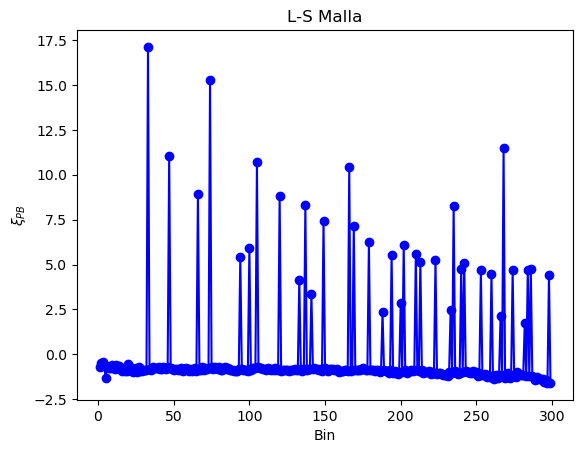

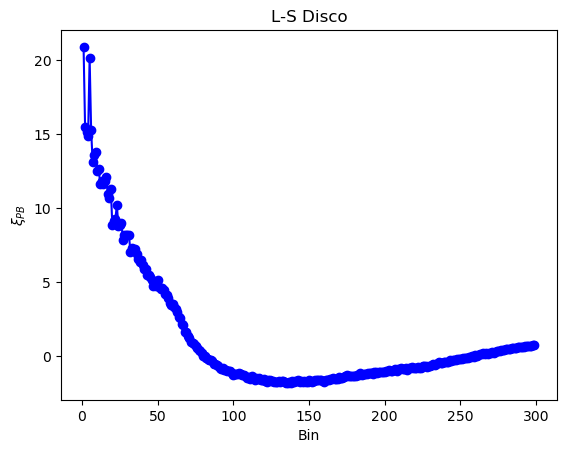

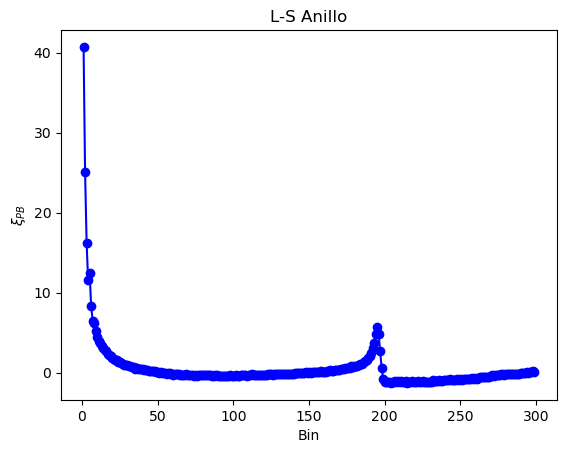

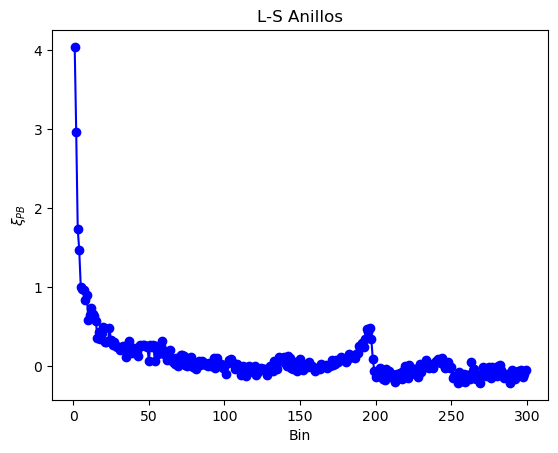

In [94]:
# Caracteristicas del anillo

r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
num_centros=10 #Numero de centros o anillos a graficar

#Caracteristicas Generales

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=1000 #Tamaño de la grafica
num_pG=1000 #Numero de puntos de datos 
num_p_a=10000 #Numero de puntos aleatorios (10 veces el numero de datos)

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

# Malla Cuadriculada 

Histo_PuntosDRMalla =  Histo_DR(dim_hist, num_p_malla, num_p_a, puntos_malla, puntos_RR, bin_size) #DR Malla
l_DRMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRMalla=l_DRMalla+Histo_PuntosDRMalla[k]

Histo_Punto_DRMalla_N=Histo_PuntosDRMalla/l_DRMalla # DR normalizado

Histo_PuntosDMalla = Histo_distancias(dim, dim_hist, num_p_malla, puntos_malla, bin_size)  

l_DMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DMalla=l_DMalla+Histo_PuntosDMalla[k]

Histo_Punto_DMalla_N=Histo_PuntosDMalla/l_DMalla # DD normalizado

PlebesH_DMalla=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_DMalla[i]=1+Histo_Punto_DMalla_N[i]/Histo_PuntosRR_N[i]-2*Histo_Punto_DRMalla_N[i]/Histo_PuntosRR_N[i]

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_DMalla[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Malla")
plt.show()

#Disco

Histo_PuntosDRDisco =  Histo_DR(dim_hist, num_pG, num_p_a, pDD_disco, puntos_RR, bin_size) #DR Malla
l_DRDisco=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRDisco=l_DRDisco+Histo_PuntosDRDisco[k]

Histo_Punto_DRDisco_N=Histo_PuntosDRDisco/l_DRDisco # DR normalizado

Histo_PuntosDDisco = Histo_distancias(dim, dim_hist, num_pG, pDD_disco, bin_size)  

l_DDisco=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DDisco=l_DDisco+Histo_PuntosDDisco[k]

Histo_Punto_DDisco_N=Histo_PuntosDDisco/l_DDisco # DD normalizado

PlebesH_Disco=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Disco[i]=1+Histo_Punto_DDisco_N[i]/Histo_PuntosRR_N[i]-2*Histo_Punto_DRDisco_N[i]/Histo_PuntosRR_N[i]

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Disco[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Disco")
plt.show()

#Anillo

Histo_PuntosDRAnillo =  Histo_DR(dim_hist, num_pG, num_p_a, pDD_anillo, puntos_RR, bin_size) #DR Malla
l_DRAnillo=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillo=l_DRAnillo+Histo_PuntosDRAnillo[k]

Histo_Punto_DRAnillo_N=Histo_PuntosDRAnillo/l_DRAnillo # DR normalizado 

Histo_PuntosDAnillo= Histo_distancias(dim, dim_hist, num_pG, pDD_anillo, bin_size)  

l_DAnillo=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillo=l_DAnillo+Histo_PuntosDAnillo[k]

Histo_Punto_DAnillo_N=Histo_PuntosDAnillo/l_DAnillo # DD normalizado

PlebesH_Anillo=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Anillo[i]=1+Histo_Punto_DAnillo_N[i]/Histo_PuntosRR_N[i]-2*Histo_Punto_DRAnillo_N[i]/Histo_PuntosRR_N[i]

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Anillo[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Anillo")
plt.show()

#Anillos

num_pDD_anillos=num_pa*num_centros

Histo_PuntosDRAnillos =  Histo_DR(dim_hist, num_pG, num_pDD_anillos, pDD_anillos, puntos_RR, bin_size) #DR Malla
l_DRAnillos=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillos=l_DRAnillos+Histo_PuntosDRAnillos[k]

Histo_Punto_DRAnillos_N=Histo_PuntosDRAnillos/l_DRAnillos # DR normalizado 

Histo_PuntosDAnillos = Histo_distancias(dim, dim_hist, num_pDD_anillos, pDD_anillos, bin_size)  #Obtiene el histograma de los datos (los anillos generados)

l_DAnillos=0

for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillos=l_DAnillos+Histo_PuntosDAnillos[k]

Histo_Punto_DAnillos_N=Histo_PuntosDAnillos/l_DAnillos # DD normalizado

PlebesH_Anillos=uwu.zeros(dim_hist)  #Lista que guardara los calculos del la funcion Peebles-Hausler 

for i in range(1,dim_hist):
    PlebesH_Anillos[i]=1+(Histo_Punto_DAnillos_N[i]/Histo_PuntosRR_N[i])-2*(Histo_Punto_DRAnillos_N[i]/Histo_PuntosRR_N[i])


plt.plot(range(1, dim_hist), PlebesH_Anillos[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Anillos")
plt.show()

#### 4.-) Observar como cambia la función de correlación con el número de puntos aleatorios.

##### a) Usando 1 archivo con 1, 5, 10 y 50 veces el número de puntos que los datos, y promedia los histogramas

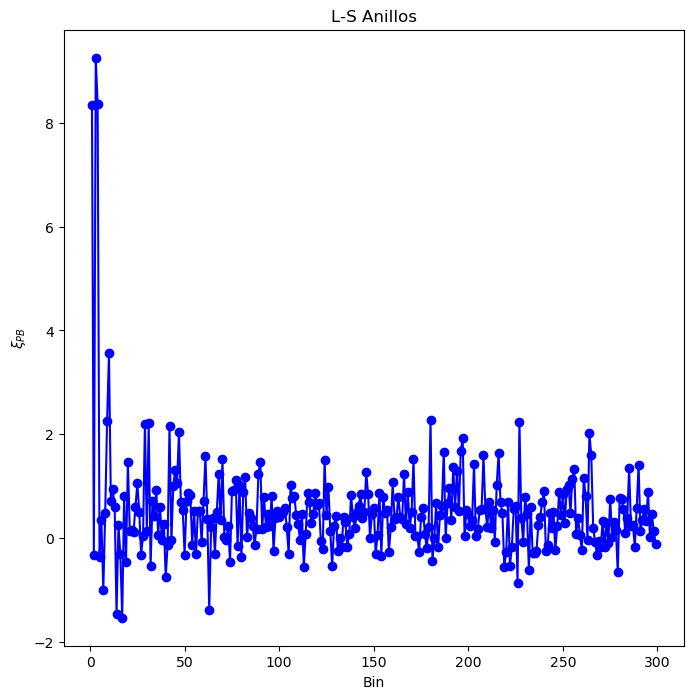

In [97]:
#Vamos a usar Landy-Szalay para hacer el analisis (Promedio de Histogramas)

# Caracteristicas del anillo
r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 10  # Cantidad de puntos en cada anillo
num_centros=5 #Numero de centros o anillos a graficar


bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=1000 #Tamaño de la grafica
num_Datos=int(num_pa*num_centros) #Numero de puntos de datos 
num_R1=50 #Numero de puntos aleatorios (10 veces el numero de datos)
num_R2=250
num_R3=500
num_R4=2500

puntos_DD = anillos_distribuidos(num_centros,tam,r1,r2,num_pa)

Histo_PuntosDD = Histo_distancias(dim, dim_hist, num_Datos, puntos_DD, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosDD=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosDD=l_PuntosDD+Histo_PuntosDD[k]

Histo_PuntosDD_N=Histo_PuntosDD/l_PuntosDD #Histograma de la muestra aleatoria normalizada

puntos_R1 = spawn_puntos(num_R1, dim, tam)
puntos_R2 = spawn_puntos(num_R2, dim, tam)
puntos_R3 = spawn_puntos(num_R3, dim, tam)
puntos_R4 = spawn_puntos(num_R4, dim, tam)

#Caja x1

Histo_PuntosDR1 =  Histo_DR(dim_hist, num_Datos, num_R1, puntos_DD, puntos_R1, bin_size) #DR Malla
l_DR1=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DR1=l_DR1+Histo_PuntosDR1[k]

Histo_Punto_DR1_N=Histo_PuntosDR1/l_DR1 # DR normalizado

Histo_PuntosR1 = Histo_distancias(dim, dim_hist, num_R1, puntos_R1, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosR1=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosR1=l_PuntosR1+Histo_PuntosR1[k]

Histo_PuntosR1_N=Histo_PuntosR1/l_PuntosR1 #RR Normalizdo

#Caja x5

Histo_PuntosDR2 =  Histo_DR(dim_hist, num_Datos, num_R2, puntos_DD, puntos_R2, bin_size) #DR Malla
l_DR2=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DR2=l_DR2+Histo_PuntosDR2[k]

Histo_Punto_DR2_N=Histo_PuntosDR2/l_DR2 # DR normalizado

Histo_PuntosR2 = Histo_distancias(dim, dim_hist, num_R2, puntos_R2, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosR2=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosR2=l_PuntosR2+Histo_PuntosR2[k]

Histo_PuntosR2_N=Histo_PuntosR2/l_PuntosR2 #Histograma de la muestra aleatoria normalizada

#Caja x10

Histo_PuntosDR3 =  Histo_DR(dim_hist, num_Datos, num_R3, puntos_DD, puntos_R3, bin_size) #DR Malla
l_DR3=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DR3=l_DR3+Histo_PuntosDR3[k]

Histo_Punto_DR3_N=Histo_PuntosDR1/l_DR3 # DR normalizado

Histo_PuntosR3 = Histo_distancias(dim, dim_hist, num_R3, puntos_R3, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosR3=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosR3=l_PuntosR3+Histo_PuntosR3[k]

Histo_PuntosR3_N=Histo_PuntosR3/l_PuntosR3 #Histograma de la muestra aleatoria normalizada

#Caja x50

Histo_PuntosDR4 =  Histo_DR(dim_hist, num_Datos, num_R4, puntos_DD, puntos_R4, bin_size) #DR Malla
l_DR4=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DR4=l_DR4+Histo_PuntosDR4[k]

Histo_Punto_DR4_N=Histo_PuntosDR4/l_DR4 # DR normalizado

Histo_PuntosR4 = Histo_distancias(dim, dim_hist, num_R4, puntos_R4, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosR4=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosR4=l_PuntosR4+Histo_PuntosR4[k]

Histo_PuntosR4_N=Histo_PuntosR4/l_PuntosR4 #Histograma de la muestra aleatoria normalizada

#Promedio del histograma RR
Prom_HistRR=uwu.zeros(dim_hist)
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    Prom_HistRR[k]=(Histo_PuntosR1_N[k]+Histo_PuntosR2_N[k]+Histo_PuntosR3_N[k]+Histo_PuntosR4_N[k])/4

#Promedio del histograma DR
Prom_HistDR=uwu.zeros(dim_hist)
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    Prom_HistDR[k]=(Histo_Punto_DR1_N[k]+Histo_Punto_DR2_N[k]+Histo_Punto_DR3_N[k]+Histo_Punto_DR4_N[k])/4

PlebesH_DatosProm=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_DatosProm[i]=1+(Histo_PuntosDD_N[i]/Prom_HistRR[i])-2*(Prom_HistDR[i]/Prom_HistRR[i])

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_DatosProm[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$") #Se uso el ultimo estimador
plt.title("L-S Anillos")
plt.show()

##### b) Usando 1 archivo con 1, 5, 10 y 50 veces el número de puntos que los datos, y promedia las funciones de correlación 

C:\Users\saibo\AppData\Local\Temp\ipykernel_5008\600925287.py:55: RuntimeWarning: invalid value encountered in scalar divide
  PlebesH_Datos1[i]=1+(Histo_PuntosDD_N[i]/Histo_PuntosR1_N[i])-2*(Histo_Punto_DR1_N[i]/Histo_PuntosR1_N[i])
C:\Users\saibo\AppData\Local\Temp\ipykernel_5008\600925287.py:55: RuntimeWarning: divide by zero encountered in scalar divide
  PlebesH_Datos1[i]=1+(Histo_PuntosDD_N[i]/Histo_PuntosR1_N[i])-2*(Histo_Punto_DR1_N[i]/Histo_PuntosR1_N[i])
C:\Users\saibo\AppData\Local\Temp\ipykernel_5008\600925287.py:55: RuntimeWarning: invalid value encountered in scalar subtract
  PlebesH_Datos1[i]=1+(Histo_PuntosDD_N[i]/Histo_PuntosR1_N[i])-2*(Histo_Punto_DR1_N[i]/Histo_PuntosR1_N[i])


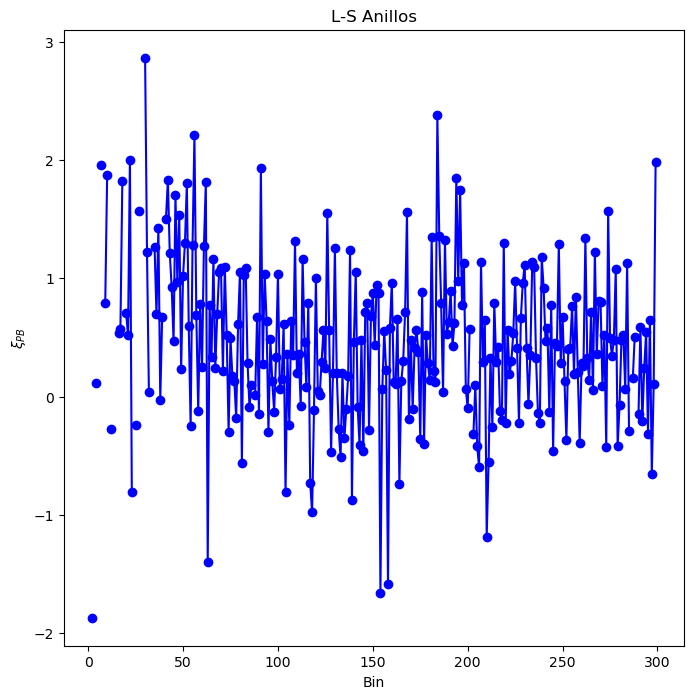

In [99]:
# (Promedio de las funciones de correlacion)

# Caracteristicas del anillo
r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 10  # Cantidad de puntos en cada anillo
tam=1000   #Tamaño del grafico
num_centros=5 #Numero de centros o anillos a graficar

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=1000 #Tamaño de la grafica
num_Datos=50 #Numero de puntos de datos 
num_R1=50 #Numero de puntos aleatorios (10 veces el numero de datos)
num_R2=250
num_R3=500
num_R4=2500

puntos_DD = anillos_distribuidos(num_centros,tam,r1,r2,num_pa)

Histo_PuntosDD = Histo_distancias(dim, dim_hist, num_Datos, puntos_DD, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosDD=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosDD=l_PuntosDD+Histo_PuntosDD[k]

Histo_PuntosDD_N=Histo_PuntosDD/l_PuntosDD #Histograma de la muestra aleatoria normalizada

puntos_R1 = spawn_puntos(num_R1, dim, tam)
puntos_R2 = spawn_puntos(num_R2, dim, tam)
puntos_R3 = spawn_puntos(num_R3, dim, tam)
puntos_R4 = spawn_puntos(num_R4, dim, tam)

#Caja x1

Histo_PuntosDR1 =  Histo_DR(dim_hist, num_Datos, num_R1, puntos_DD, puntos_R1, bin_size) #DR Malla
l_DR1=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DR1=l_DR1+Histo_PuntosDR1[k]

Histo_Punto_DR1_N=Histo_PuntosDR1/l_DR1 # DR normalizado

Histo_PuntosR1 = Histo_distancias(dim, dim_hist, num_R1, puntos_R1, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosR1=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosR1=l_PuntosR1+Histo_PuntosR1[k]

Histo_PuntosR1_N=Histo_PuntosR1/l_PuntosR1 #RR Normalizdo

PlebesH_Datos1=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Datos1[i]=1+(Histo_PuntosDD_N[i]/Histo_PuntosR1_N[i])-2*(Histo_Punto_DR1_N[i]/Histo_PuntosR1_N[i])

#Caja x5

Histo_PuntosDR2 =  Histo_DR(dim_hist, num_Datos, num_R2, puntos_DD, puntos_R2, bin_size) #DR Malla
l_DR2=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DR2=l_DR2+Histo_PuntosDR2[k]

Histo_Punto_DR2_N=Histo_PuntosDR2/l_DR2 # DR normalizado

Histo_PuntosR2 = Histo_distancias(dim, dim_hist, num_R2, puntos_R2, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosR2=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosR2=l_PuntosR2+Histo_PuntosR2[k]

Histo_PuntosR2_N=Histo_PuntosR2/l_PuntosR2 #Histograma de la muestra aleatoria normalizada

PlebesH_Datos2=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Datos2[i]=1+(Histo_PuntosDD_N[i]/Histo_PuntosR2_N[i])-2*(Histo_Punto_DR2_N[i]/Histo_PuntosR2_N[i])

#Caja x10

Histo_PuntosDR3 =  Histo_DR(dim_hist, num_Datos, num_R3, puntos_DD, puntos_R3, bin_size) #DR Malla
l_DR3=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DR3=l_DR3+Histo_PuntosDR3[k]

Histo_Punto_DR3_N=Histo_PuntosDR1/l_DR3 # DR normalizado

Histo_PuntosR3 = Histo_distancias(dim, dim_hist, num_R3, puntos_R3, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosR3=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosR3=l_PuntosR3+Histo_PuntosR3[k]

Histo_PuntosR3_N=Histo_PuntosR3/l_PuntosR3 #Histograma de la muestra aleatoria normalizada

PlebesH_Datos3=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Datos3[i]=1+(Histo_PuntosDD_N[i]/Histo_PuntosR3_N[i])-2*(Histo_Punto_DR3_N[i]/Histo_PuntosR3_N[i])

#Caja x50

Histo_PuntosDR4 =  Histo_DR(dim_hist, num_Datos, num_R4, puntos_DD, puntos_R4, bin_size) #DR Malla
l_DR4=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DR4=l_DR4+Histo_PuntosDR4[k]

Histo_Punto_DR4_N=Histo_PuntosDR4/l_DR4 # DR normalizado

Histo_PuntosR4 = Histo_distancias(dim, dim_hist, num_R4, puntos_R4, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosR4=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosR4=l_PuntosR4+Histo_PuntosR4[k]

Histo_PuntosR4_N=Histo_PuntosR4/l_PuntosR4 #Histograma de la muestra aleatoria normalizada

PlebesH_Datos4=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Datos4[i]=1+(Histo_PuntosDD_N[i]/Histo_PuntosR4_N[i])-2*(Histo_Punto_DR4_N[i]/Histo_PuntosR4_N[i])

#Promedio de la funcion 
Prom_Corre=uwu.zeros(dim_hist)
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    Prom_Corre[k]=(PlebesH_Datos1[k]+PlebesH_Datos2[k]+PlebesH_Datos3[k]+PlebesH_Datos4[k])/4


# Grafica el estimador
plt.plot(range(1, dim_hist), Prom_Corre[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$") #Se uso el ultimo estimador
plt.title("L-S Anillos")
plt.show()

##### c)  Usando 1, 5, 10 y 50 archivos de muestras aleatorias con el mismo número de puntos que los datos



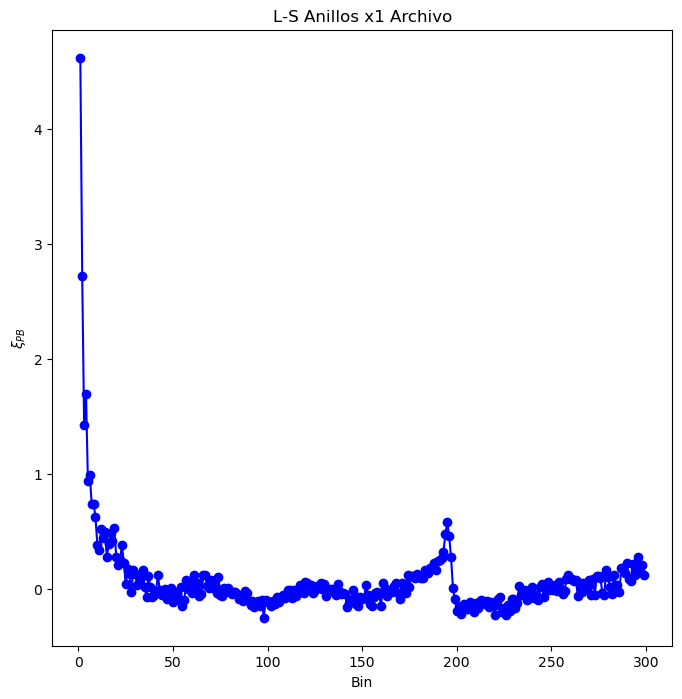

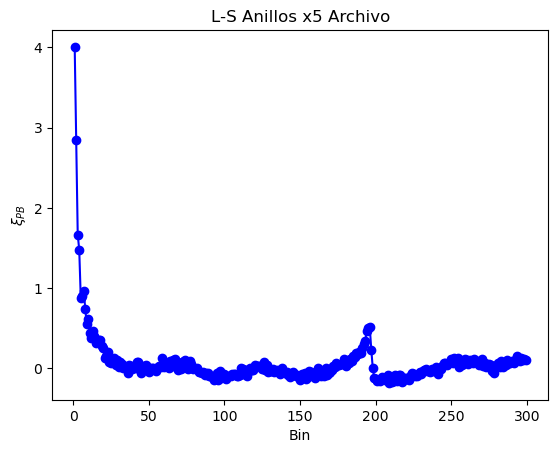

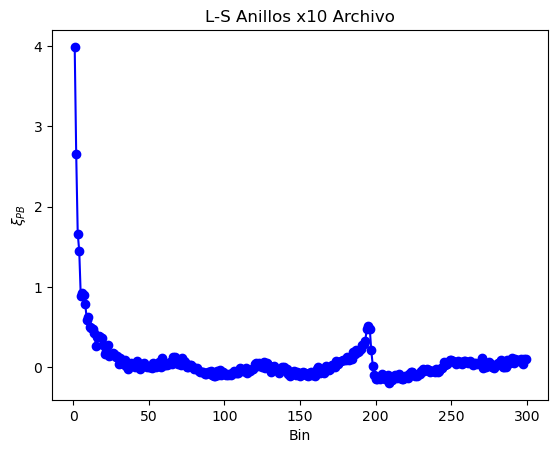

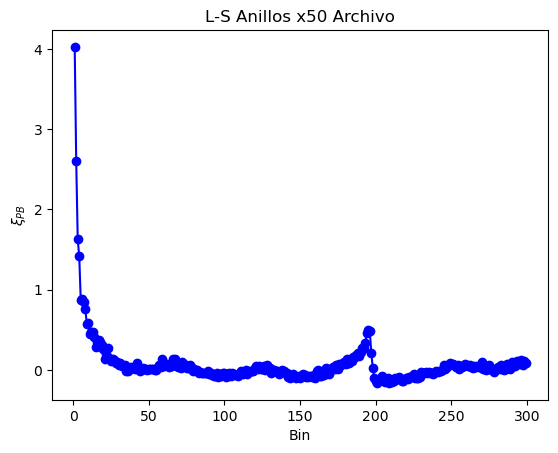

In [101]:
#Promedie los histogramas, no las funciones de correlacion
def PromedioHistogramasRR(num_arch, num_points, bin_size,dim_hist,tam):
    Histogramas=[]
    for i in range(num_arch):
        points = spawn_puntos(num_points, 2, tam)
        Histo = Histo_distancias(2, dim_hist, num_points, points, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)
        l_Histo=0
        for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
            l_Histo=l_Histo+Histo[k]
        Histo_N=Histo/l_Histo # DR normalizado
        Histogramas.append(Histo_N) #Guarda los histogramas normalizados generados
    Hist_Prom=uwu.mean(Histogramas, axis=0) #Calcula el promedio de todos los histogramas
    return Hist_Prom

def PromedioHistogramasDR(num_arch, num_points, bin_size,dim_hist,tam,puntos_DD):
    Histogramas = []
    for i in range(num_arch):
        points = spawn_puntos(num_points, 2, tam)
        Histo =  Histo_DR(dim_hist, num_points, num_points, puntos_DD, points, bin_size) #Validos solo para los dos conjuntos con el mismo numero de puntos
        l_Histo=0
        for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
            l_Histo=l_Histo+Histo[k]
        Histo_N=Histo/l_Histo # DR normalizado
        Histogramas.append(Histo_N)
    Hist_Prom=uwu.mean(Histogramas, axis=0)
    return Hist_Prom



# Caracteristicas del anillo
r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
tam=1000   #Tamaño del grafico
num_centros=10 #Numero de centros o anillos a graficar

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=1000 #Tamaño de la grafica
num_Datos=1000 #Numero de puntos de datos 


puntos_DD = anillos_distribuidos(num_centros,tam,r1,r2,num_pa)

Histo_PuntosDD = Histo_distancias(dim, dim_hist, num_Datos, puntos_DD, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosDD=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosDD=l_PuntosDD+Histo_PuntosDD[k]

Histo_PuntosDD_N=Histo_PuntosDD/l_PuntosDD #Histograma de los datos normalizada

# 1 archivo
num_arch1=1
HistoPromRR_1=PromedioHistogramasRR(num_arch1, num_Datos, bin_size,dim_hist,tam)
HistoPromDR_1= PromedioHistogramasDR(num_arch1, num_Datos, bin_size,dim_hist,tam,puntos_DD)

PlebesH_Archivo1=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Archivo1[i]=1+(Histo_PuntosDD_N[i]/HistoPromRR_1[i])-2*(HistoPromDR_1[i]/HistoPromRR_1[i])


# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Archivo1[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$") #Se uso el ultimo estimador
plt.title("L-S Anillos x1 Archivo")
plt.show()

# 5 archivos
num_arch5=5
HistoPromRR_5=PromedioHistogramasRR(num_arch5, num_Datos, bin_size,dim_hist,tam)
HistoPromDR_5= PromedioHistogramasDR(num_arch5, num_Datos, bin_size,dim_hist,tam,puntos_DD)

PlebesH_Archivo5=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Archivo5[i]=1+(Histo_PuntosDD_N[i]/HistoPromRR_5[i])-2*(HistoPromDR_5[i]/HistoPromRR_5[i])


# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Archivo5[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$") #Se uso el ultimo estimador
plt.title("L-S Anillos x5 Archivo")
plt.show()

#10 archivos 
num_arch10=10
HistoPromRR_10=PromedioHistogramasRR(num_arch10, num_Datos, bin_size,dim_hist,tam)
HistoPromDR_10= PromedioHistogramasDR(num_arch10, num_Datos, bin_size,dim_hist,tam,puntos_DD)

PlebesH_Archivo10=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Archivo10[i]=1+(Histo_PuntosDD_N[i]/HistoPromRR_10[i])-2*(HistoPromDR_10[i]/HistoPromRR_10[i])


# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Archivo10[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$") #Se uso el ultimo estimador
plt.title("L-S Anillos x10 Archivo")
plt.show()

#50 archivos 
num_arch50=50
HistoPromRR_50=PromedioHistogramasRR(num_arch50, num_Datos, bin_size,dim_hist,tam)
HistoPromDR_50= PromedioHistogramasDR(num_arch50, num_Datos, bin_size,dim_hist,tam,puntos_DD)

PlebesH_Archivo50=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_Archivo50[i]=1+(Histo_PuntosDD_N[i]/HistoPromRR_50[i])-2*(HistoPromDR_50[i]/HistoPromRR_50[i])


# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_Archivo50[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$") #Se uso el ultimo estimador
plt.title("L-S Anillos x50 Archivo")
plt.show()

#### 5.-) Integra la función de correlación sobre la distancia para cada estimaor del inciso 3 y considerando sólo los datos del inciso 1a, y 1d.

Área Malla = -53.425398438851175


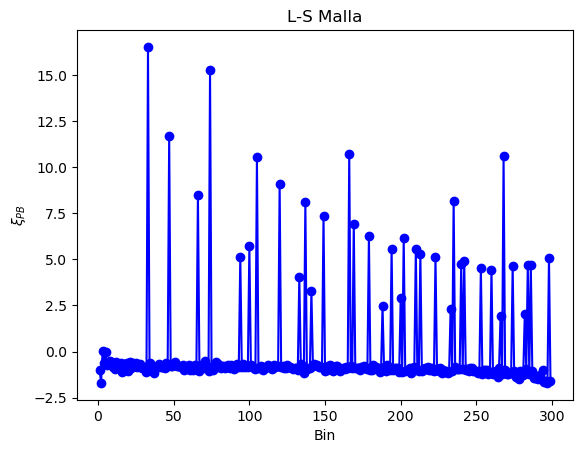

Área Anillos = 89.98704403112316


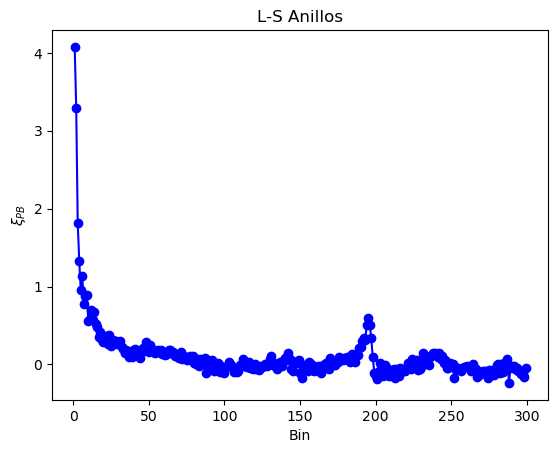

In [103]:

# Caracteristicas del anillo
r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
tam=1000   #Tamaño del grafico
num_centros=10 #Numero de centros o anillos a graficar

#Vamos a integrar el ultimo solamente

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=1000 #Tamaño de la grafica
num_pG=1000 #Numero de puntos de datos 
num_p_a=1000 #Numero de puntos aleatorios 

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

# Malla Cuadriculada 

Histo_PuntosDRMalla =  Histo_DR(dim_hist, num_p_malla, num_p_a, puntos_malla, puntos_RR, bin_size) #DR Malla
l_DRMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRMalla=l_DRMalla+Histo_PuntosDRMalla[k]

Histo_Punto_DRMalla_N=Histo_PuntosDRMalla/l_DRMalla # DR normalizado

Histo_PuntosDMalla = Histo_distancias(dim, dim_hist, num_p_malla, puntos_malla, bin_size)  

l_DMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DMalla=l_DMalla+Histo_PuntosDMalla[k]

Histo_Punto_DMalla_N=Histo_PuntosDMalla/l_DMalla # DD normalizado

PlebesH_DMalla=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_DMalla[i]=1+Histo_Punto_DMalla_N[i]/Histo_PuntosRR_N[i]-2*Histo_Punto_DRMalla_N[i]/Histo_PuntosRR_N[i]



#Anillos

num_pDD_anillos=num_pa*num_centros

Histo_PuntosDRAnillos =  Histo_DR(dim_hist, num_pG, num_pDD_anillos, pDD_anillos, puntos_RR, bin_size) #DR Malla
l_DRAnillos=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillos=l_DRAnillos+Histo_PuntosDRAnillos[k]

Histo_Punto_DRAnillos_N=Histo_PuntosDRAnillos/l_DRAnillos # DR normalizado 

Histo_PuntosDAnillos = Histo_distancias(dim, dim_hist, num_pDD_anillos, pDD_anillos, bin_size)  #Obtiene el histograma de los datos (los anillos generados)

l_DAnillos=0

for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillos=l_DAnillos+Histo_PuntosDAnillos[k]

Histo_Punto_DAnillos_N=Histo_PuntosDAnillos/l_DAnillos # DD normalizado

PlebesH_Anillos=uwu.zeros(dim_hist)  #Lista que guardara los calculos del la funcion Peebles-Hausler 

for i in range(1,dim_hist):
    PlebesH_Anillos[i]=1+(Histo_Punto_DAnillos_N[i]/Histo_PuntosRR_N[i])-2*(Histo_Punto_DRAnillos_N[i]/Histo_PuntosRR_N[i])

#Integracion de cada funcion 
Int_Malla=0
for j in range(1, dim_hist):
    Int_Malla=Int_Malla+PlebesH_DMalla[j]*bin_size #Lo integre como si fuera histograma, el valor de la funcion multiplicado por el tam del bin


Int_Anillos=0
for j in range(1, dim_hist):
    Int_Anillos=Int_Anillos+PlebesH_Anillos[j]*bin_size #Lo integre como si fuera histograma, el valor de la funcion multiplicado por el tam del bin



print(f"Área Malla = {Int_Malla}")
plt.plot(range(1, dim_hist), PlebesH_DMalla[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Malla")
plt.show()
print(f"Área Anillos = {Int_Anillos}")
plt.plot(range(1, dim_hist), PlebesH_Anillos[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Anillos")
plt.show()

#### 6.-) Modifica el tamaño de la caja a 2000 y 3000, manteniendo la densidad constante de puntos con respecto al inciso 1), calcula de nuevo las funciones de correlación para cada estimador del inciso 2) y comparalas, considerando sólo los datos del inciso 1a, y 1d.

##### Nos centraremos solo en el ultimo estimador. Para la caja de 2000:

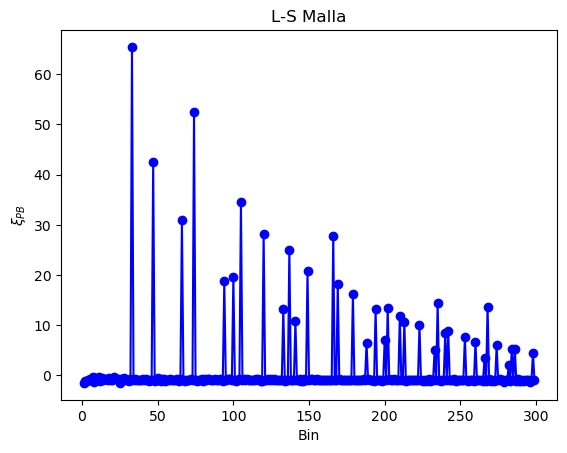

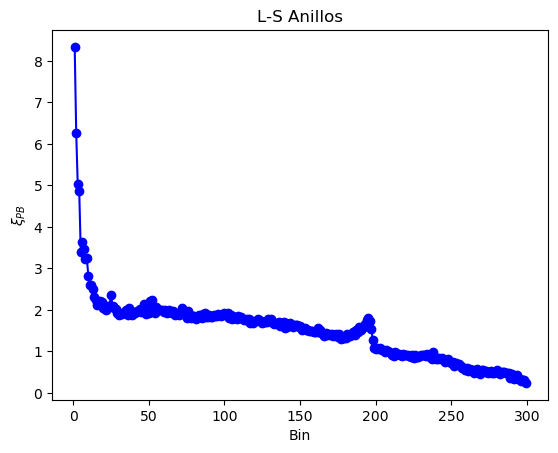

In [106]:
#Caracteristicas del anillo 

r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
num_centros=20 #Numero de centros o anillos a grafica

#Caracteristicas generales

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=2000 #Tamaño de la grafica
num_pG=2000 #Numero de puntos de datos, la densidad es de p=1/2000
num_p_a=2000 #Numero de puntos aleatorios

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

# Malla Cuadriculada 

Histo_PuntosDRMalla =  Histo_DR(dim_hist, num_p_malla, num_p_a, puntos_malla, puntos_RR, bin_size) #DR Malla
l_DRMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRMalla=l_DRMalla+Histo_PuntosDRMalla[k]

Histo_Punto_DRMalla_N=Histo_PuntosDRMalla/l_DRMalla # DR normalizado

Histo_PuntosDMalla = Histo_distancias(dim, dim_hist, num_p_malla, puntos_malla, bin_size)  

l_DMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DMalla=l_DMalla+Histo_PuntosDMalla[k]

Histo_Punto_DMalla_N=Histo_PuntosDMalla/l_DMalla # DD normalizado

PlebesH_DMalla=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_DMalla[i]=1+Histo_Punto_DMalla_N[i]/Histo_PuntosRR_N[i]-2*Histo_Punto_DRMalla_N[i]/Histo_PuntosRR_N[i]

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_DMalla[1:], marker='o', color='b',linestyle="solid")  #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Malla")
plt.show()


#Anillos

num_pDD_anillos=num_pa*num_centros

Histo_PuntosDRAnillos =  Histo_DR(dim_hist, num_pG, num_pDD_anillos, pDD_anillos, puntos_RR, bin_size) #DR Malla
l_DRAnillos=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillos=l_DRAnillos+Histo_PuntosDRAnillos[k]

Histo_Punto_DRAnillos_N=Histo_PuntosDRAnillos/l_DRAnillos # DR normalizado 

Histo_PuntosDAnillos = Histo_distancias(dim, dim_hist, num_pDD_anillos, pDD_anillos, bin_size)  #Obtiene el histograma de los datos (los anillos generados)

l_DAnillos=0

for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillos=l_DAnillos+Histo_PuntosDAnillos[k]

Histo_Punto_DAnillos_N=Histo_PuntosDAnillos/l_DAnillos # DD normalizado

PlebesH_Anillos=uwu.zeros(dim_hist)  #Lista que guardara los calculos del la funcion Peebles-Hausler 

for i in range(1,dim_hist):
    PlebesH_Anillos[i]=1+(Histo_Punto_DAnillos_N[i]/Histo_PuntosRR_N[i])-2*(Histo_Punto_DRAnillos_N[i]/Histo_PuntosRR_N[i])


plt.plot(range(1, dim_hist), PlebesH_Anillos[1:], marker='o', color='b',linestyle="solid")   #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Anillos")
plt.show()

##### Para la caja de 3000:

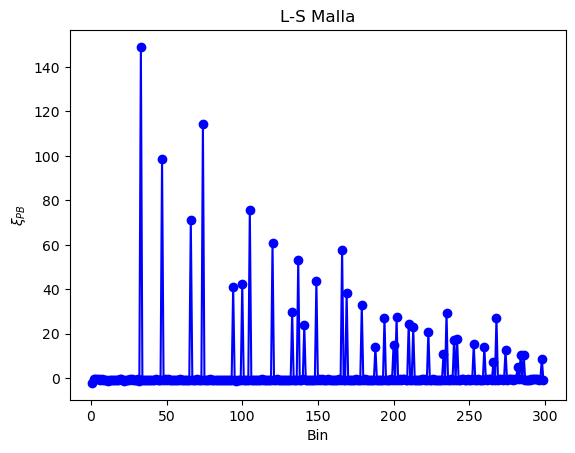

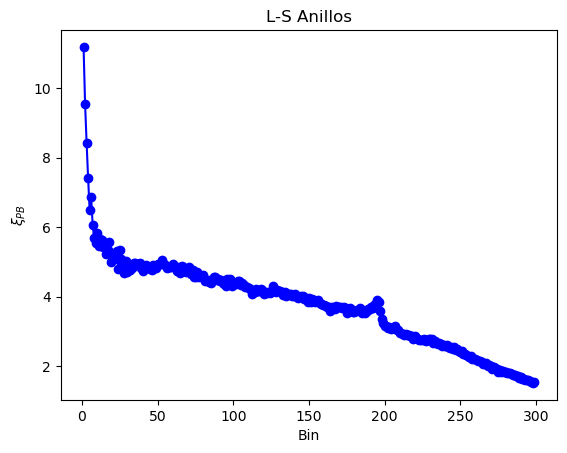

In [108]:
#Caracteristicas del anillo

r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa =100   # Cantidad de puntos en cada anillo
num_centros=45 #Numero de centros o anillos a graficar


#Caracteristicas generales 

bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
dim=2 # Dimension del grafico
tam=3000 #Tamaño de la grafica
num_pG=4500 #Numero de puntos de datos #Densidad constante de 1/2000
num_p_a=4500 #Numero de puntos aleatorios (10 veces el numero de datos)

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

puntos_RR = spawn_puntos(num_p_a, dim, tam)

Histo_PuntosRR = Histo_distancias(dim, dim_hist, num_pG, puntos_RR, bin_size)  #Obtiene el histograma deL la muestra aleatoria (la caja con puntos)

l_PuntosRR=0
for k in range(dim_hist): #Calcula el numero total de distancias (frecuencias) de la muestra aleatoria.
    l_PuntosRR=l_PuntosRR+Histo_PuntosRR[k]

Histo_PuntosRR_N=Histo_PuntosRR/l_PuntosRR #Histograma de la muestra aleatoria normalizada

# Malla Cuadriculada 

Histo_PuntosDRMalla =  Histo_DR(dim_hist, num_p_malla, num_p_a, puntos_malla, puntos_RR, bin_size) #DR Malla
l_DRMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRMalla=l_DRMalla+Histo_PuntosDRMalla[k]

Histo_Punto_DRMalla_N=Histo_PuntosDRMalla/l_DRMalla # DR normalizado

Histo_PuntosDMalla = Histo_distancias(dim, dim_hist, num_p_malla, puntos_malla, bin_size)  

l_DMalla=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DMalla=l_DMalla+Histo_PuntosDMalla[k]

Histo_Punto_DMalla_N=Histo_PuntosDMalla/l_DMalla # DD normalizado

PlebesH_DMalla=uwu.zeros(dim_hist)  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,dim_hist): #Calcula la funcion de Peebles-Hausler
    PlebesH_DMalla[i]=1+Histo_Punto_DMalla_N[i]/Histo_PuntosRR_N[i]-2*Histo_Punto_DRMalla_N[i]/Histo_PuntosRR_N[i]

# Grafica el estimador
plt.plot(range(1, dim_hist), PlebesH_DMalla[1:], marker='o', color='b',linestyle="solid")   #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Malla")
plt.show()


#Anillos

num_pDD_anillos=num_pa*num_centros

Histo_PuntosDRAnillos =  Histo_DR(dim_hist, num_pG, num_pDD_anillos, pDD_anillos, puntos_RR, bin_size) #DR Malla
l_DRAnillos=0
for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DRAnillos=l_DRAnillos+Histo_PuntosDRAnillos[k]

Histo_Punto_DRAnillos_N=Histo_PuntosDRAnillos/l_DRAnillos # DR normalizado 

Histo_PuntosDAnillos = Histo_distancias(dim, dim_hist, num_pDD_anillos, pDD_anillos, bin_size)  #Obtiene el histograma de los datos (los anillos generados)

l_DAnillos=0

for k in range(dim_hist): #Calcula el numero total de distancias calculadas (frecuencias).
    l_DAnillos=l_DAnillos+Histo_PuntosDAnillos[k]

Histo_Punto_DAnillos_N=Histo_PuntosDAnillos/l_DAnillos # DD normalizado

PlebesH_Anillos=uwu.zeros(dim_hist)  #Lista que guardara los calculos del la funcion Peebles-Hausler 

for i in range(1,dim_hist):
    PlebesH_Anillos[i]=1+(Histo_Punto_DAnillos_N[i]/Histo_PuntosRR_N[i])-2*(Histo_Punto_DRAnillos_N[i]/Histo_PuntosRR_N[i])


plt.plot(range(1, dim_hist), PlebesH_Anillos[1:], marker='o', color='b',linestyle="solid")   #Grafica los datos desde His[1] hasta Hist[dim_hist-1] respecto al bin correspondiente.
plt.xlabel("Bin")
plt.ylabel(r"$\xi_{PB}$")
plt.title("L-S Anillos")
plt.show()